Task vectors

name: FengPengchao

In [1]:
import torch
import os
from collections import OrderedDict

def flatten_state_dict(d, parent_key='', sep='@'):
    """递归展开嵌套 OrderedDict"""
    items = []
    for k, v in d.items():
        new_key = parent_key + sep + str(k) if parent_key else str(k)
        if isinstance(v, (OrderedDict, dict)):
            flattened = flatten_state_dict(v, new_key, sep)
            items.extend(flattened.items())
        else:
            items.append((new_key, v))
    return dict(items)

def unflatten_state_dict(flat_dict, sep='@'):
    """将扁平化的 state_dict 恢复为嵌套 dict"""
    unflat = dict()
    for flat_key, value in flat_dict.items():
        parts = flat_key.split(sep)
        d = unflat
        for part in parts[:-1]:
            if part not in d or not isinstance(d[part], dict):
                d[part] = dict()
            d = d[part]
        d[parts[-1]] = value
    return unflat


def load_state_dict(path):
    """读取模型"""
    print(f"[info] Loading model from: {path}")
    checkpoint = torch.load(path, map_location='cpu')
    if isinstance(checkpoint, (dict, OrderedDict)):
        return flatten_state_dict(checkpoint)
        

def compare_models(model_dir, model1, model2):
    """比较微调前后模型的数值差距"""
    state_dict1 = load_state_dict(os.path.join(model_dir,model1))
    state_dict2 = load_state_dict(os.path.join(model_dir,model2))

    diff_dict = {}
    diff_norms = {}

    for key in state_dict1:
        if key not in state_dict2:
            print(f"[info] model2 中缺少参数: {key}")
            continue

        param1, param2 = state_dict1[key], state_dict2[key]

        if not isinstance(param1, torch.Tensor) or not isinstance(param2, torch.Tensor):
            print(f"[info] 参数 {key} 不是 Tensor 类型，跳过")
            continue

        if param1.shape != param2.shape:
            print(f"[info] 参数维度不一致: {key}: {param1.shape} vs {param2.shape}")
            continue

        if not torch.is_floating_point(param1):
            print(f"[info] 非浮点类型参数: {key}: {param1} (dtype = {param1.dtype})")
            # print(f"[info] {key} 参数量：{param1.numel()} 形式：{param1.size()}")
            continue

        diff = param2 - param1
        diff_dict[key] = diff
        # print(f"[info] {key} 参数量：{diff.numel()} 形式：{diff.size()}")
        diff_norms[key] = torch.norm(diff).item() 
    
    # print(f"[info] 模型参数：{diff_norms}")
    # diff_path = os.path.join(output_dir, 'model_diff.pt')
    # torch.save(diff, diff_path)
    # print(f"[info] 差值已保存: {diff_path}")

    # 统计
    print("\n=== 各层参数差值的 L2 范数 (自上而下排序) ===")
    for key, norm in sorted(diff_norms.items(), key=lambda item: item[1], reverse=True):
        print(f"{key}: ||diff|| = {norm:.6f}")

    return state_dict1, state_dict2, diff_dict, diff_norms

def assert_nested_dict_equal(d1, d2):
    """验证两个模型的结构相同"""
    assert isinstance(d1, dict) and isinstance(d2, dict), "Both should be dicts"
    assert d1.keys() == d2.keys(), f"Keys mismatch: {d1.keys()} != {d2.keys()}"
    
    for k in d1:
        v1, v2 = d1[k], d2[k]
        if isinstance(v1, dict) and isinstance(v2, dict):
            assert_nested_dict_equal(v1, v2)  # 递归比较
        else:
            # assert v1 == v2, f"Values mismatch at key {k}: {v1} != {v2}"
            continue
    

In [ ]:
# test 展开和恢复
state = torch.load(model1_path, map_location='cpu')
flat = flatten_state_dict(state)
restored = unflatten_state_dict(flat)
            
assert_nested_dict_equal(state, restored)

In [5]:
# interpolate
model_dir = "/hpc_stor03/sjtu_home/pengchao.feng/LearningCourse/F5-TTS/ckpts/F5TTS_v1_Small_shanghai/"
model1 = 'pretrained_model_1200000.pt'
model2 = 'model_80000.pt'
alpha = 3
beta = 1.0
norm_flag = False
model1_flag = model1 == 'pretrained_model_1200000.pt'

state_dict1, state_dict2, diff_dict, diff_norms = compare_models(model_dir, model1, model2)

interpolated = {}
for k, v in state_dict1.items():
    if k in diff_dict:
        if norm_flag:
            interpolated[k] = v + alpha * diff_dict[k] ** beta * diff_norms[k]
        else:
            interpolated[k] = v + alpha * diff_dict[k] ** beta
    else:
        interpolated[k] = v
        
interpolated_nested = unflatten_state_dict(interpolated)
if model1_flag:
    interpolated_name = f'interpolated_{model2}_a{alpha:.1f}_b{beta:.1f}_n{str(norm_flag)}.pt'
else:
    interpolated_name = f'interpolated_{model2}_a{alpha:.1f}_b{beta:.1f}_n{str(norm_flag)}_{model1}.pt'
interpolated_path = os.path.join(model_dir, interpolated_name)
torch.save(interpolated_nested, interpolated_path)

state_dict1, state_dict2, diff_dict, diff_norms = compare_models(model_dir, 'pretrained_model_1200000.pt', interpolated_name)
print(f"\n 插值模型已保存: {interpolated_path}")

[info] Loading model from: /hpc_stor03/sjtu_home/pengchao.feng/LearningCourse/F5-TTS/ckpts/F5TTS_v1_Small_shanghai/pretrained_model_1200000.pt
[info] Loading model from: /hpc_stor03/sjtu_home/pengchao.feng/LearningCourse/F5-TTS/ckpts/F5TTS_v1_Small_shanghai/model_80000.pt
[info] 非浮点类型参数: ema_model_state_dict@initted: True (dtype = torch.bool)
[info] 非浮点类型参数: ema_model_state_dict@step: 1200000 (dtype = torch.int64)

=== 各层参数差值的 L2 范数 (自上而下排序) ===
ema_model_state_dict@ema_model.transformer.transformer_blocks.17.ff.ff.0.0.weight: ||diff|| = 1.762595
ema_model_state_dict@ema_model.transformer.transformer_blocks.17.attn_norm.linear.weight: ||diff|| = 1.653833
ema_model_state_dict@ema_model.transformer.transformer_blocks.16.ff.ff.0.0.weight: ||diff|| = 1.559468
ema_model_state_dict@ema_model.transformer.transformer_blocks.16.attn_norm.linear.weight: ||diff|| = 1.535977
ema_model_state_dict@ema_model.transformer.transformer_blocks.17.ff.ff.2.weight: ||diff|| = 1.475113
ema_model_state_dict@em

[info] Loading model from: /hpc_stor03/sjtu_home/pengchao.feng/LearningCourse/F5-TTS/ckpts/F5TTS_v1_Small/model_80000.pt
[info] Loading model from: /hpc_stor03/sjtu_home/pengchao.feng/LearningCourse/F5-TTS/ckpts/F5TTS_v1_Small/model_60000.pt
[info] 参数 optimizer_state_dict@param_groups 不是 Tensor 类型，跳过
[info] 非浮点类型参数: ema_model_state_dict@initted: True (dtype = torch.bool)
[info] 非浮点类型参数: ema_model_state_dict@step: 1280000 (dtype = torch.int64)
[info] 参数 scheduler_state_dict@_milestones 不是 Tensor 类型，跳过
[info] 参数 scheduler_state_dict@last_epoch 不是 Tensor 类型，跳过
[info] 参数 scheduler_state_dict@_last_lr 不是 Tensor 类型，跳过
[info] 参数 scheduler_state_dict@_schedulers 不是 Tensor 类型，跳过
[info] 参数 update 不是 Tensor 类型，跳过

=== 各层参数差值的 L2 范数 (自上而下排序) ===
optimizer_state_dict@state@0@step: ||diff|| = 20000.000000
optimizer_state_dict@state@1@step: ||diff|| = 20000.000000
optimizer_state_dict@state@2@step: ||diff|| = 20000.000000
optimizer_state_dict@state@3@step: ||diff|| = 20000.000000
optimizer_state_dict

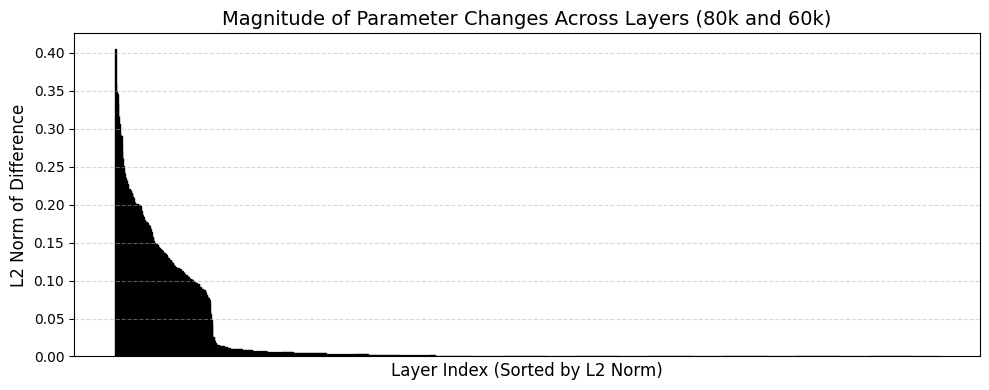

In [14]:
import matplotlib.pyplot as plt

def visualize_diff_norms(diff_norms):
    # sort
    sorted_items = sorted(diff_norms.items(), key=lambda item: item[1], reverse=True)
    values = []
    for _,v in sorted_items:
        if v < 10:
            values.append(v)

    # Plot
    plt.figure(figsize=(10, 4))
    plt.bar(range(len(values)), values, color="#4682B4", edgecolor="black")
    plt.xlabel("Layer Index (Sorted by L2 Norm)", fontsize=12)
    plt.ylabel("L2 Norm of Difference", fontsize=12)
    plt.title("Magnitude of Parameter Changes Across Layers (80k and 60k)", fontsize=14)
    plt.xticks([])  # Hide x-axis tick labels for a cleaner look
    plt.grid(axis="y", linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()


model_dir = "/hpc_stor03/sjtu_home/pengchao.feng/LearningCourse/F5-TTS/ckpts/F5TTS_v1_Small/"
state_dict1, state_dict2, diff_dict, diff_norms = compare_models(model_dir, 'model_80000.pt', 'model_60000.pt')
visualize_diff_norms(diff_norms)

In [18]:
model_dir = "/hpc_stor03/sjtu_home/pengchao.feng/LearningCourse/F5-TTS/ckpts/F5TTS_v1_Small/"
state_dict10, state_dict20, diff_dict0, diff_norms0 = compare_models(model_dir, 'model_100000.pt', 'model_80000.pt')

value = []
for k,v in diff_norms.items():
    if v < 10:
        value.append(v-diff_norms0[k])
print("L2 Norm bia:", sum([v**2 for v in value]) / len(value))

[info] Loading model from: /hpc_stor03/sjtu_home/pengchao.feng/LearningCourse/F5-TTS/ckpts/F5TTS_v1_Small/model_100000.pt


[info] Loading model from: /hpc_stor03/sjtu_home/pengchao.feng/LearningCourse/F5-TTS/ckpts/F5TTS_v1_Small/model_80000.pt
[info] 参数 optimizer_state_dict@param_groups 不是 Tensor 类型，跳过
[info] 非浮点类型参数: ema_model_state_dict@initted: True (dtype = torch.bool)
[info] 非浮点类型参数: ema_model_state_dict@step: 1300000 (dtype = torch.int64)
[info] 参数 scheduler_state_dict@_milestones 不是 Tensor 类型，跳过
[info] 参数 scheduler_state_dict@last_epoch 不是 Tensor 类型，跳过
[info] 参数 scheduler_state_dict@_last_lr 不是 Tensor 类型，跳过
[info] 参数 scheduler_state_dict@_schedulers 不是 Tensor 类型，跳过
[info] 参数 update 不是 Tensor 类型，跳过

=== 各层参数差值的 L2 范数 (自上而下排序) ===
optimizer_state_dict@state@0@step: ||diff|| = 20000.000000
optimizer_state_dict@state@1@step: ||diff|| = 20000.000000
optimizer_state_dict@state@2@step: ||diff|| = 20000.000000
optimizer_state_dict@state@3@step: ||diff|| = 20000.000000
optimizer_state_dict@state@4@step: ||diff|| = 20000.000000
optimizer_state_dict@state@5@step: ||diff|| = 20000.000000
optimizer_state_dict@st